# Week 34: introduction, notations and definitions -- selected codes

**FYS4480/FYS9480, Quantum mechanics for many-particle systems**
Morten Hjorth-Jensen, Department of Physics and Center for Computing in Science Education, University of Oslo

This notebook accompanies the week-34 slides (`week34.tex`) and chapters 1 and 2 of the lecture notes. Every numerical statement made in the lectures is checked here, in the order of the slides:

1. Vectors, inner and outer products, Dirac notation
2. Projection operators, density matrices and Pauli matrices
3. Unitary transformations: orthogonality, norm and spectrum are preserved
4. Tensor products and the exponential wall
5. Determinants: definition versus algorithm, linearity and the product rule
6. A single-particle basis and the Slater determinant: antisymmetry, Pauli principle, occupation numbers
7. Changing the basis: $\det(\mathbf{C})\det(\mathbf{\Phi})$ and the invariance of the energy
8. The energy functional, a minimal self-consistent field loop, and the correlation energy

The code is written in a compact object-oriented style and uses only `numpy` (and `matplotlib` for two figures). The full versions of the classes in sections 6-8 are in `BookPrograms/chapter02/slaterdeterminant.py`, which additionally uses the Householder/QL eigenvalue solver of chapter 1 instead of `numpy.linalg.eigh`.

Index counting starts at zero throughout, exactly as in the lecture notes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True, linewidth=120)
rng = np.random.default_rng(2026)

## 1. Vectors, inner and outer products, Dirac notation

A ket $|x\rangle$ is a column vector, the bra $\langle x|$ its Hermitian conjugate (a row vector), the inner product $\langle y|x\rangle=\sum_i y_i^*x_i$ and the outer product $|x\rangle\langle y|$ a matrix with elements $x_iy_j^*$. We reproduce the worked examples of the slides.

In [2]:
def ket(*components):
    '''A column vector (ket) from its components.'''
    return np.array(components, dtype=complex).reshape(-1, 1)

def bra(k):
    '''The Hermitian conjugate of a ket: a row vector.'''
    return k.conj().T

def inner(y, x):
    '''<y|x> as a complex number.'''
    return (bra(y) @ x)[0, 0]

def outer(x, y):
    '''|x><y| as a matrix.'''
    return x @ bra(y)

x = ket(1 - 1j, 2 + 1j)
print("<x|x> =", inner(x, x), "  (real, as it must be)")
print("normalised |x> =", (x / np.sqrt(inner(x, x).real)).ravel())

x = ket(-1, 2j, 1)
y = ket(1, 0, 1j)
print("<x|y> =", inner(x, y), "   <y|x> =", inner(y, x), "   <x|y>* == <y|x> ?", np.isclose(inner(x, y).conj(), inner(y, x)))
print("outer product |x><y| =\n", outer(x, y))
print("trace of |x><y| =", np.trace(outer(x, y)), " equals <y|x> =", inner(y, x))

<x|x> = (7+0j)   (real, as it must be)
normalised |x> = [0.377964-0.377964j 0.755929+0.377964j]
<x|y> = (-1+1j)    <y|x> = (-1-1j)    <x|y>* == <y|x> ? True
outer product |x><y| =
 [[-1.+0.j  0.+0.j  0.+1.j]
 [ 0.+2.j  0.+0.j  2.+0.j]
 [ 1.+0.j  0.+0.j  0.-1.j]]
trace of |x><y| = (-1-1j)  equals <y|x> = (-1-1j)


## 2. Projection operators, density matrices and Pauli matrices

With the computational basis $|0\rangle$, $|1\rangle$ we build the projectors $\mathbf{P}=|0\rangle\langle 0|$ and $\mathbf{Q}=|1\rangle\langle 1|$, check idempotency, $\mathbf{P}+\mathbf{Q}=\mathbf{I}$, $\mathbf{PQ}=0$, and act on a superposition $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$. Then the density matrix $\rho=|\psi\rangle\langle\psi|$, and finally all the properties of the Pauli matrices listed on the slides.

In [3]:
zero, one = ket(1, 0), ket(0, 1)
P, Q = outer(zero, zero), outer(one, one)
I2 = np.eye(2)

print("P =\n", P.real, "\nQ =\n", Q.real)
print("P^2 == P:", np.allclose(P @ P, P), "  Q^2 == Q:", np.allclose(Q @ Q, Q))
print("P + Q == I:", np.allclose(P + Q, I2), "  P Q == 0:", np.allclose(P @ Q, 0))
print("det P =", np.linalg.det(P).real, " -> a projector is not invertible, hence not unitary")

alpha, beta = 0.6, 0.8j          # |alpha|^2 + |beta|^2 = 1
psi = alpha * zero + beta * one
print("\n|psi> =", psi.ravel(), "  <psi|psi> =", inner(psi, psi).real)
print("P|psi> =", (P @ psi).ravel(), " = alpha|0>")
print("Q|psi> =", (Q @ psi).ravel(), " = beta |1>")

rho = outer(psi, psi)
print("\nrho = |psi><psi| =\n", rho)
print("tr rho =", np.trace(rho).real, "  rho^2 == rho (pure state):", np.allclose(rho @ rho, rho))
print("probabilities of measuring 0 and 1:", np.diag(rho).real)

P =
 [[1. 0.]
 [0. 0.]] 
Q =
 [[0. 0.]
 [0. 1.]]
P^2 == P: True   Q^2 == Q: True
P + Q == I: True   P Q == 0: True
det P = 0.0  -> a projector is not invertible, hence not unitary

|psi> = [0.6+0.j  0. +0.8j]   <psi|psi> = 1.0
P|psi> = [0.6+0.j 0. +0.j]  = alpha|0>
Q|psi> = [0.+0.j  0.+0.8j]  = beta |1>

rho = |psi><psi| =
 [[0.36+0.j   0.  -0.48j]
 [0.  +0.48j 0.64+0.j  ]]
tr rho = 1.0   rho^2 == rho (pure state): True
probabilities of measuring 0 and 1: [0.36 0.64]


/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/numpy/linalg/linalg.py:2146: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/mhjensen/miniforge3/envs/myenv/lib/python3.9/site-packages/numpy/linalg/linalg.py:2146: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [4]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]], dtype=complex)
paulis = {"x": sx, "y": sy, "z": sz}

def commutator(A, B):
    return A @ B - B @ A

def anticommutator(A, B):
    return A @ B + B @ A

for name, s in paulis.items():
    print(f"sigma_{name}: involutory {np.allclose(s @ s, I2)}, Hermitian {np.allclose(s, s.conj().T)}, "
          f"unitary {np.allclose(s.conj().T @ s, I2)}, det = {np.linalg.det(s).real:+.0f}, "
          f"eigenvalues {np.linalg.eigvalsh(s)}")

print("\n[sx, sy] == 2i sz:", np.allclose(commutator(sx, sy), 2j * sz))
print("[sy, sz] == 2i sx:", np.allclose(commutator(sy, sz), 2j * sx))
print("[sz, sx] == 2i sy:", np.allclose(commutator(sz, sx), 2j * sy))
print("{sx, sy} == 0:", np.allclose(anticommutator(sx, sy), 0), "  {sx, sx} == 2I:", np.allclose(anticommutator(sx, sx), 2 * I2))

# pause-to-think #3: sigma_x acting on the density matrix
rho_prime = sx @ rho @ sx.conj().T
print("\nsigma_x rho sigma_x^dagger =\n", rho_prime)
print("equals |psi'><psi'| with |psi'> = sigma_x|psi>:", np.allclose(rho_prime, outer(sx @ psi, sx @ psi)))
print("trace preserved:", np.isclose(np.trace(rho_prime).real, 1.0), "  purity preserved:", np.allclose(rho_prime @ rho_prime, rho_prime))

sigma_x: involutory True, Hermitian True, unitary True, det = -1, eigenvalues [-1.  1.]
sigma_y: involutory True, Hermitian True, unitary True, det = -1, eigenvalues [-1.  1.]
sigma_z: involutory True, Hermitian True, unitary True, det = -1, eigenvalues [-1.  1.]

[sx, sy] == 2i sz: True
[sy, sz] == 2i sx: True
[sz, sx] == 2i sy: True
{sx, sy} == 0: True   {sx, sx} == 2I: True

sigma_x rho sigma_x^dagger =
 [[0.64+0.j   0.  +0.48j]
 [0.  -0.48j 0.36+0.j  ]]
equals |psi'><psi'| with |psi'> = sigma_x|psi>: True
trace preserved: True   purity preserved: True


## 3. Unitary transformations

A unitary matrix satisfies $\mathbf{U}^\dagger\mathbf{U}=\mathbf{I}$. We draw a random unitary (by QR-decomposing a random complex matrix), rotate an orthonormal basis with it, and check the three statements of the lectures and of exercise 1:

* the rotated basis is still orthonormal, $\langle\psi_p|\psi_q\rangle=\delta_{pq}$;
* the norm of any state is preserved;
* the eigenvalues of a Hermitian operator are unchanged under $\mathbf{O}\to\mathbf{U}\mathbf{O}\mathbf{U}^\dagger$, and the eigenvectors are the rotated ones.

In [5]:
def random_unitary(n, rng):
    '''A Haar-random n x n unitary matrix from the QR decomposition of a complex Gaussian matrix.'''
    Z = rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))
    Qm, R = np.linalg.qr(Z)
    return Qm * (np.diag(R) / np.abs(np.diag(R)))   # fix the phases so the distribution is uniform

def random_hermitian(n, rng):
    A = rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))
    return (A + A.conj().T) / 2

n = 4
U = random_unitary(n, rng)
print("U^dagger U == I:", np.allclose(U.conj().T @ U, np.eye(n)), "   |det U| =", abs(np.linalg.det(U)))
print("eigenvalues of U have modulus one:", np.abs(np.linalg.eigvals(U)))

# an orthonormal basis: the columns of the identity (the computational basis)
phi = np.eye(n, dtype=complex)
psi = U @ phi                                       # rotated basis, psi_p = U phi_p
print("\nGram matrix of the rotated basis (should be the identity):\n", np.round(psi.conj().T @ psi, 12).real)

# norm preserved for an arbitrary state
v = rng.normal(size=(n, 1)) + 1j * rng.normal(size=(n, 1))
print("\n<v|v> =", inner(v, v).real, "  <Uv|Uv> =", inner(U @ v, U @ v).real)

# eigenvalues unchanged under the similarity transformation  O' = U O U^dagger
O = random_hermitian(n, rng)
Oprime = U @ O @ U.conj().T
print("\neigenvalues of O :", np.linalg.eigvalsh(O))
print("eigenvalues of O':", np.linalg.eigvalsh(Oprime))
vals, vecs = np.linalg.eigh(O)
print("O' (U phi_lambda) == o_lambda (U phi_lambda):",
      np.allclose(Oprime @ (U @ vecs), (U @ vecs) * vals))

U^dagger U == I: True    |det U| = 0.9999999999999997
eigenvalues of U have modulus one: [1. 1. 1. 1.]

Gram matrix of the rotated basis (should be the identity):
 [[ 1.  0. -0. -0.]
 [ 0.  1.  0.  0.]
 [-0.  0.  1. -0.]
 [-0.  0. -0.  1.]]

<v|v> = 4.746402323415756   <Uv|Uv> = 4.746402323415756

eigenvalues of O : [-2.491758 -0.309089  0.645826  4.675932]
eigenvalues of O': [-2.491758 -0.309089  0.645826  4.675932]
O' (U phi_lambda) == o_lambda (U phi_lambda): True


## 4. Tensor products and the exponential wall

`numpy.kron` is the tensor (Kronecker) product. We build the four two-qubit basis states, check that they form an orthonormal basis of $\mathbb{C}^4$, test whether a given two-qubit state is a product state by the rank of its $2\times 2$ amplitude matrix (pause to think #5), and count how many qubits fit in a given amount of memory.

In [6]:
basis2 = {f"|{a}{b}>": np.kron(s, t) for a, s in (("0", zero), ("1", one)) for b, t in (("0", zero), ("1", one))}
for name, v in basis2.items():
    print(name, "=", v.ravel().real)
G = np.array([[inner(u, v).real for v in basis2.values()] for u in basis2.values()])
print("Gram matrix == identity:", np.allclose(G, np.eye(4)))

def is_product_state(state2q):
    '''A two-qubit state |Psi> = sum_ij Psi_ij |i>|j> is a product state iff the matrix Psi_ij has rank one.'''
    Psi = state2q.reshape(2, 2)
    return np.linalg.matrix_rank(Psi, tol=1e-12) == 1

x, y = ket(0.6, 0.8), ket(1 / np.sqrt(2), 1j / np.sqrt(2))
product = np.kron(x, y)
bell = (basis2["|00>"] + basis2["|11>"]) / np.sqrt(2)
print("\n|x>|y>  is a product state:", is_product_state(product))
print("(|00>+|11>)/sqrt2 is a product state:", is_product_state(bell), " -> entangled")

# the exponential wall: 16 bytes per complex amplitude
for memory, label in ((16 * 2**30, "16 GB laptop"), (10 * 2**50, "10 PB supercomputer")):
    N = int(np.floor(np.log2(memory / 16)))
    print(f"{label}: at most N = {N} qubits ({2**N:.2e} amplitudes)")

from math import comb
print("\nnumber of Slater determinants for N particles in n orbitals:")
for n, N in ((8, 2), (8, 4), (20, 10), (40, 20), (100, 50)):
    print(f"  n = {n:3d}, N = {N:2d}:  C(n,N) = {comb(n, N):.3e}")

|00> = [1. 0. 0. 0.]
|01> = [0. 1. 0. 0.]
|10> = [0. 0. 1. 0.]
|11> = [0. 0. 0. 1.]
Gram matrix == identity: True

|x>|y>  is a product state: True
(|00>+|11>)/sqrt2 is a product state: False  -> entangled
16 GB laptop: at most N = 30 qubits (1.07e+09 amplitudes)
10 PB supercomputer: at most N = 49 qubits (5.63e+14 amplitudes)

number of Slater determinants for N particles in n orbitals:
  n =   8, N =  2:  C(n,N) = 2.800e+01
  n =   8, N =  4:  C(n,N) = 7.000e+01
  n =  20, N = 10:  C(n,N) = 1.848e+05
  n =  40, N = 20:  C(n,N) = 1.378e+11
  n = 100, N = 50:  C(n,N) = 1.009e+29


## 5. Determinants: definition versus algorithm

The determinant is defined as a signed sum over all $n!$ permutations of the column indices,
$$\det(\mathbf{A})=\sum_{P}(-1)^{p}\,a_{1P(1)}a_{2P(2)}\cdots a_{nP(n)}.$$
We implement this definition literally (never do this in production!), compare it with `numpy.linalg.det` (LU decomposition, $\mathcal{O}(n^3)$), time both, and then verify numerically the two properties used in the lectures: linearity in a column and the product rule $\det(\mathbf{BC})=\det(\mathbf{B})\det(\mathbf{C})$.

In [7]:
from itertools import permutations
import time

def permutation_parity(perm):
    '''Number of transpositions (mod 2) needed to sort the permutation: 0 for even, 1 for odd.'''
    perm = list(perm)
    parity = 0
    for i in range(len(perm)):
        while perm[i] != i:
            j = perm[i]
            perm[i], perm[j] = perm[j], perm[i]
            parity ^= 1
    return parity

def det_by_definition(A):
    '''The O(n!) permutation sum.  Educational only.'''
    n = A.shape[0]
    total = 0.0
    for perm in permutations(range(n)):
        term = (-1) ** permutation_parity(perm)
        for i in range(n):
            term *= A[i, perm[i]]
        total += term
    return total

for n in (2, 3, 5, 7, 8):
    A = rng.normal(size=(n, n))
    t0 = time.perf_counter(); d1 = det_by_definition(A); t1 = time.perf_counter()
    d2 = np.linalg.det(A); t2 = time.perf_counter()
    print(f"n = {n}: definition {d1:+.10f} in {t1 - t0:8.4f} s,  LU {d2:+.10f} in {t2 - t1:.2e} s,  agree {np.isclose(d1, d2)}")

n = 2: definition +1.6788495263 in   0.0000 s,  LU +1.6788495263 in 3.29e-04 s,  agree True
n = 3: definition -0.3736555592 in   0.0000 s,  LU -0.3736555592 in 4.03e-05 s,  agree True
n = 5: definition +0.8370071987 in   0.0002 s,  LU +0.8370071987 in 1.42e-05 s,  agree True
n = 7: definition -41.9767768310 in   0.0111 s,  LU -41.9767768310 in 6.41e-05 s,  agree True
n = 8: definition -40.7536709514 in   0.1254 s,  LU -40.7536709514 in 5.82e-05 s,  agree True


In [8]:
# linearity in a column, and the product rule (exercise 2a)
n = 4
A = rng.normal(size=(n, n)); B = rng.normal(size=(n, n)); C = rng.normal(size=(n, n))
c = rng.normal(size=n)

# replace column 1 of A by sum_k c_k b_k  (b_k = columns of B)
A1 = A.copy(); A1[:, 1] = B @ c
rhs = sum(c[k] * np.linalg.det(np.column_stack([A[:, 0], B[:, k], A[:, 2], A[:, 3]])) for k in range(n))
print("linearity in a column:", np.isclose(np.linalg.det(A1), rhs))
print("product rule det(BC) = det(B) det(C):", np.isclose(np.linalg.det(B @ C), np.linalg.det(B) * np.linalg.det(C)))

# swapping two columns flips the sign; two equal columns give zero
As = A[:, [1, 0, 2, 3]]
print("column swap flips the sign:", np.isclose(np.linalg.det(As), -np.linalg.det(A)))
Ae = A.copy(); Ae[:, 2] = Ae[:, 0]
print("two equal columns -> det =", np.linalg.det(Ae))

# and for a unitary matrix |det| = 1
U = random_unitary(n, rng)
print("|det U| =", abs(np.linalg.det(U)))

linearity in a column: True
product rule det(BC) = det(B) det(C): True
column swap flips the sign: True
two equal columns -> det = 1.3787287955920943e-16
|det U| = 0.9999999999999992


## 6. A single-particle basis and the Slater determinant

We use the model of the lecture notes: spinless fermions in a one-dimensional harmonic trap, $\hat h_0=-\tfrac12\,d^2/dx^2+\tfrac12x^2$, whose eigenfunctions are the Hermite functions with $\varepsilon_n=n+\tfrac12$, and a softened Coulomb repulsion $v(x,y)=g/\sqrt{(x-y)^2+a^2}$. The basis is represented on a grid, and the two-body matrix elements
$$\langle pq|v|rs\rangle=\int\!\!\int \phi_p(x)\phi_q(y)\,v(x,y)\,\phi_r(x)\phi_s(y)\,dx\,dy$$
are computed as one matrix product of the pair densities $\rho_{pr}(x)=\phi_p(x)\phi_r(x)$ with the kernel. (This is the compact version of `HarmonicOscillatorBasis` in `slaterdeterminant.py`.)

|S - I| = 9.010461701370788e-16  (orthonormal to quadrature accuracy)
single-particle energies: [0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5]


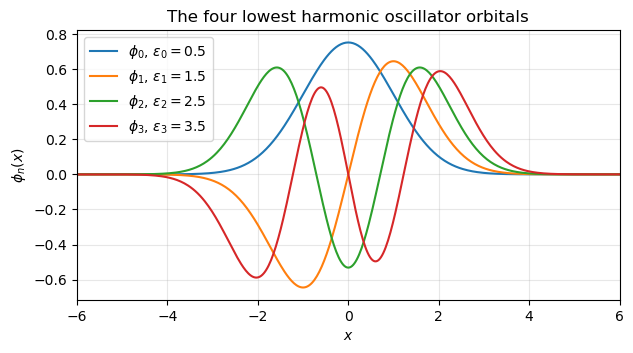

In [9]:
class HarmonicOscillatorBasis:
    '''Hermite functions on a grid; one- and two-body matrix elements for a local interaction.'''

    def __init__(self, n_orb=8, n_grid=601, rmax=8.0, strength=1.0, softening=0.5):
        self.n_orb, self.strength, self.softening = n_orb, strength, softening
        self.x, self.h = np.linspace(-rmax, rmax, n_grid, retstep=True)
        self.phi = self._hermite_functions()
        self.epsilon = np.arange(n_orb) + 0.5

    def _hermite_functions(self):
        x, n = self.x, self.n_orb
        phi = np.zeros((n, len(x)))
        gauss = np.exp(-x**2 / 2)
        H_prev, H = np.zeros_like(x), np.ones_like(x)
        for k in range(n):                       # H_{k+1} = 2x H_k - 2k H_{k-1}
            phi[k] = H * gauss
            H_prev, H = H, 2 * x * H - 2 * k * H_prev
        return phi / np.sqrt(self.h * np.sum(phi**2, axis=1))[:, None]

    @property
    def overlap(self):
        return self.h * self.phi @ self.phi.T

    @property
    def one_body(self):
        return np.diag(self.epsilon)             # <p|h_0|q> = eps_p delta_pq

    def two_body(self):
        '''v[p,q,r,s] = <pq|v|rs>, not antisymmetrised.'''
        n, x, h = self.n_orb, self.x, self.h
        K = self.strength / np.sqrt((x[:, None] - x[None, :])**2 + self.softening**2)
        rho = (self.phi[:, None, :] * self.phi[None, :, :]).reshape(n * n, -1)   # rho_{pr}(x)
        V = h**2 * rho @ K @ rho.T                                                 # V[(pr),(qs)]
        return V.reshape(n, n, n, n).transpose(0, 2, 1, 3)

    @staticmethod
    def antisymmetrize(v):
        '''<pq|v|rs>_AS = <pq|v|rs> - <pq|v|sr>.'''
        return v - v.transpose(0, 1, 3, 2)

basis = HarmonicOscillatorBasis(n_orb=8)
print("|S - I| =", np.linalg.norm(basis.overlap - np.eye(basis.n_orb)), " (orthonormal to quadrature accuracy)")
print("single-particle energies:", basis.epsilon)

fig, ax = plt.subplots(figsize=(7, 3.5))
for k in range(4):
    ax.plot(basis.x, basis.phi[k], label=rf"$\phi_{k}$, $\varepsilon_{k}={basis.epsilon[k]}$")
ax.set_xlim(-6, 6); ax.set_xlabel("$x$"); ax.set_ylabel(r"$\phi_n(x)$"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("The four lowest harmonic oscillator orbitals")
plt.show()

The Slater determinant
$$\Phi(x_1,\dots,x_N)=\frac{1}{\sqrt{N!}}\det\bigl[\psi_i(x_j)\bigr]$$
is evaluated directly from its definition, with the orbitals $\psi_i=\sum_\lambda C_{i\lambda}\phi_\lambda$ interpolated from the grid. This is all we need to check antisymmetry, the Pauli principle, and that the occupation numbers (eigenvalues of $\rho_{\lambda\mu}=\sum_i C^*_{i\lambda}C_{i\mu}$) are exactly ones and zeros.

In [10]:
from math import factorial

class SlaterDeterminant:
    '''An N-particle determinant built from orbitals psi_i = sum_lambda C[i, lambda] phi_lambda.'''

    def __init__(self, basis, occupied, coefficients=None):
        self.basis, self.occupied = basis, list(occupied)
        self.N = len(self.occupied)
        if coefficients is None:
            C = np.zeros((self.N, basis.n_orb))
            for i, p in enumerate(self.occupied):
                C[i, p] = 1.0
            self.C = C
        else:
            self.C = np.asarray(coefficients, dtype=float)

    def orbitals_on_grid(self):
        return self.C @ self.basis.phi

    def evaluate(self, coordinates):
        psi = self.orbitals_on_grid()
        M = np.array([[np.interp(xj, self.basis.x, psi[i]) for xj in coordinates] for i in range(self.N)])
        return np.linalg.det(M) / np.sqrt(factorial(self.N))

    def density_matrix(self):
        return self.C.T @ self.C

    def occupation_numbers(self):
        return np.sort(np.linalg.eigvalsh(self.density_matrix()))[::-1]

Phi = SlaterDeterminant(basis, [0, 1, 2])
coords = [0.4, -1.1, 2.0]
a, b = Phi.evaluate(coords), Phi.evaluate([coords[1], coords[0], coords[2]])
print(f"Phi(x1,x2,x3) = {a:+.10f}")
print(f"Phi(x2,x1,x3) = {b:+.10f}")
print(f"sum           = {a + b:+.2e}   (antisymmetry)")

repeated = SlaterDeterminant(basis, [0, 1, 1])
print(f"two particles in orbital 1: Phi = {repeated.evaluate(coords):+.2e}   (Pauli principle)")
print("occupation numbers:", np.round(Phi.occupation_numbers(), 12))

Phi(x1,x2,x3) = -0.1756062188
Phi(x2,x1,x3) = +0.1756062188
sum           = +0.00e+00   (antisymmetry)
two particles in orbital 1: Phi = -6.29e-18   (Pauli principle)
occupation numbers: [1. 1. 1. 0. 0. 0. 0. 0.]


## 7. Changing the basis: $\det(\mathbf{C})\det(\mathbf{\Phi})$

The energy functional
$$E[\Phi]=\sum_{i}\langle i|\hat h_0|i\rangle+\frac12\sum_{ij}\langle ij|\hat v|ij\rangle_{\rm AS}
=\sum_{i}\sum_{\alpha\beta}C^*_{i\alpha}C_{i\beta}\langle\alpha|\hat h_0|\beta\rangle
+\frac12\sum_{ij}\sum_{\alpha\beta\gamma\delta}C^*_{i\alpha}C^*_{j\beta}C_{i\gamma}C_{j\delta}\langle\alpha\beta|\hat v|\gamma\delta\rangle_{\rm AS}$$
is a function of the coefficients $C_{i\lambda}$ (rows = occupied orbitals). A unitary rotation **within** the occupied space multiplies the determinant by the phase $\det(\mathbf{C})$ and cannot change the energy; a rotation that **mixes** occupied and unoccupied orbitals changes the state, and the energy.

In [11]:
class EnergyFunctional:
    '''E[Psi] for a Slater determinant with occupied orbitals given by the rows of C.'''

    def __init__(self, basis):
        self.basis = basis
        self.h = basis.one_body
        self.v = basis.antisymmetrize(basis.two_body())

    def energy(self, C):
        C = np.asarray(C, dtype=float)
        one = np.einsum("ia,ib,ab->", C, C, self.h)
        two = np.einsum("ia,jb,ic,jd,abcd->", C, C, C, C, self.v)
        return one + 0.5 * two

    def energy_from_occupied(self, occupied):
        occ = list(occupied)
        return sum(self.h[i, i] for i in occ) + 0.5 * sum(self.v[i, j, i, j] for i in occ for j in occ)

    def fock_matrix(self, C):
        rho = C.T @ C                                   # density matrix
        return self.h + np.einsum("cd,acbd->ab", rho, self.v)

functional = EnergyFunctional(basis)
N = 3
C0 = np.eye(basis.n_orb)[:N]
E0 = functional.energy(C0)
print(f"E[Phi] from the sum over occupied states = {functional.energy_from_occupied(range(N)):.12f}")
print(f"E[Psi] from the coefficient formula      = {E0:.12f}")

# an orthogonal rotation within the occupied space
Qocc, _ = np.linalg.qr(rng.normal(size=(N, N)))
E1 = functional.energy(Qocc @ C0)
print(f"\ndet(Q) = {np.linalg.det(Qocc):+.10f}")
print(f"E[Phi] original basis = {E0:.12f}")
print(f"E[Phi] rotated basis  = {E1:.12f}     difference = {abs(E1 - E0):.2e}")

# a rotation mixing occupied and unoccupied orbitals
Qfull, _ = np.linalg.qr(rng.normal(size=(basis.n_orb, basis.n_orb)))
E2 = functional.energy(Qfull[:, :N].T)
print(f"E[Phi] occupied-virtual mixing = {E2:.12f}   -- this one changes")

# the two-body array: n^4 numbers, but the pair matrix has low rank
n = basis.n_orb
pair = basis.two_body().transpose(0, 2, 1, 3).reshape(n * n, n * n)
print(f"\ntwo-body matrix elements stored: n^4 = {n**4};  numerical rank of the {n*n} x {n*n} pair matrix = "
      f"{np.linalg.matrix_rank(pair, tol=1e-10)}")

E[Phi] from the sum over occupied states = 6.468010213126
E[Psi] from the coefficient formula      = 6.468010213126

det(Q) = +1.0000000000
E[Phi] original basis = 6.468010213126
E[Phi] rotated basis  = 6.468010213126     difference = 8.88e-16
E[Phi] occupied-virtual mixing = 14.967223615739   -- this one changes

two-body matrix elements stored: n^4 = 4096;  numerical rank of the 64 x 64 pair matrix = 15


## 8. A minimal self-consistent field loop, and the correlation energy

Minimising $E[\Psi]$ with respect to the coefficients (subject to orthonormality) gives the Hartree-Fock equations: the optimal coefficients are the lowest $N$ eigenvectors of the Fock matrix
$$f_{\alpha\beta}=\langle\alpha|\hat h_0|\beta\rangle+\sum_{\gamma\delta}\rho_{\gamma\delta}\langle\alpha\gamma|\hat v|\beta\delta\rangle_{\rm AS},\qquad
\rho_{\gamma\delta}=\sum_i C^*_{i\gamma}C_{i\delta},$$
which itself depends on them. So: guess, build $\mathbf{f}$, diagonalise, rebuild, repeat. Hartree-Fock theory proper comes later in the course; this is only a preview of the fact that it is a repeated eigenvalue problem.

For $N=2$ the exact ground state in the same truncated basis is obtained by diagonalising $\hat H$ in the space of antisymmetric pairs $|pq\rangle$, $p<q$. The difference $E_{\rm corr}=E_{\rm exact}-E_{\rm HF}$ is the **correlation energy**.

In [12]:
class HartreeFock:
    '''Guess, build the Fock matrix, diagonalise, repeat.'''

    def __init__(self, functional, n_particles, max_iter=200, tol=1e-10):
        self.functional, self.N, self.max_iter, self.tol = functional, n_particles, max_iter, tol

    def solve(self):
        n = self.functional.basis.n_orb
        C, energy_old, self.history = np.eye(n)[:self.N], np.inf, []
        for k in range(self.max_iter):
            eps, vecs = np.linalg.eigh(self.functional.fock_matrix(C))
            C = vecs[:, :self.N].T
            energy = self.functional.energy(C)
            self.history.append(energy)
            if abs(energy - energy_old) < self.tol:
                break
            energy_old = energy
        self.iterations, self.C, self.epsilon = k + 1, C, eps
        return energy, C

def exact_two_particle(functional):
    '''Exact ground state of two spinless fermions in the truncated basis (antisymmetric pairs p<q).'''
    n = functional.basis.n_orb
    pairs = [(p, q) for p in range(n) for q in range(p + 1, n)]
    h, v = functional.h, functional.v
    H = np.zeros((len(pairs), len(pairs)))
    for a, (p, q) in enumerate(pairs):
        for b, (r, s) in enumerate(pairs):
            elem = v[p, q, r, s]
            if q == s: elem += h[p, r]
            if p == r: elem += h[q, s]
            if q == r: elem -= h[p, s]
            if p == s: elem -= h[q, r]
            H[a, b] = elem
    vals, vecs = np.linalg.eigh(H)
    return vals[0], vecs[:, 0], pairs

print("Hartree-Fock as a repeated eigenvalue problem:")
for N in (2, 3, 4):
    hf = HartreeFock(functional, N)
    E, C = hf.solve()
    E_ref = functional.energy_from_occupied(range(N))
    print(f"  N = {N}:  E(lowest N orbitals) = {E_ref:12.8f}   E(Hartree-Fock) = {E:12.8f}   "
          f"gain = {E - E_ref:+.2e}   ({hf.iterations} iterations)")

hf = HartreeFock(functional, 2); E_hf, _ = hf.solve()
E_exact, psi2, pairs = exact_two_particle(functional)
print(f"\nN = 2:  E(Hartree-Fock) = {E_hf:.10f}   E(exact, same basis) = {E_exact:.10f}")
print(f"        correlation energy = {E_exact - E_hf:+.10f}")
print(f"        largest amplitude  = {np.max(np.abs(psi2)):.6f} on the pair {pairs[int(np.argmax(np.abs(psi2)))]}")

Hartree-Fock as a repeated eigenvalue problem:
  N = 2:  E(lowest N orbitals) =   2.69018342   E(Hartree-Fock) =   2.66308878   gain = -2.71e-02   (9 iterations)
  N = 3:  E(lowest N orbitals) =   6.46801021   E(Hartree-Fock) =   6.39016133   gain = -7.78e-02   (9 iterations)
  N = 4:  E(lowest N orbitals) =  11.77084712   E(Hartree-Fock) =  11.62305385   gain = -1.48e-01   (9 iterations)

N = 2:  E(Hartree-Fock) = 2.6630887806   E(exact, same basis) = 2.6592304859
        correlation energy = -0.0038582947
        largest amplitude  = 0.992981 on the pair (0, 1)


Finally we turn the interaction strength $g$ up and watch the single determinant fail: the correlation energy grows quadratically from zero (second-order perturbation theory), and the weight of the leading determinant in the exact state drops below one.

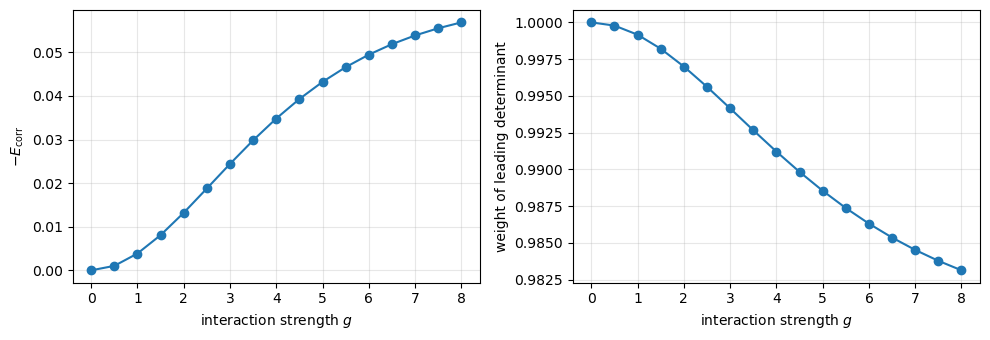

g =  0.0:  E_corr = +0.0000e+00   leading weight = 1.0000
g =  2.0:  E_corr = -1.3199e-02   leading weight = 0.9970
g =  4.0:  E_corr = -3.4816e-02   leading weight = 0.9912
g =  6.0:  E_corr = -4.9462e-02   leading weight = 0.9863
g =  8.0:  E_corr = -5.6864e-02   leading weight = 0.9831


In [13]:
strengths = np.linspace(0, 8, 17)
corr, weight = [], []
for g in strengths:
    b_g = HarmonicOscillatorBasis(n_orb=8, strength=g)
    f_g = EnergyFunctional(b_g)
    E_hf, C_hf = HartreeFock(f_g, 2).solve()
    E_ex, psi_ex, pairs_g = exact_two_particle(f_g)
    corr.append(E_ex - E_hf)
    # weight of the leading determinant: sum of the two largest natural occupation numbers
    n = b_g.n_orb
    rho = np.zeros((n, n))
    for a, (p, q) in enumerate(pairs_g):
        for b, (r, s) in enumerate(pairs_g):
            c = psi_ex[a] * psi_ex[b]
            if q == s: rho[p, r] += c
            if p == r: rho[q, s] += c
            if q == r: rho[p, s] -= c
            if p == s: rho[q, r] -= c
    occ = np.sort(np.linalg.eigvalsh(rho))[::-1]
    weight.append((occ[0] + occ[1]) / 2)          # normalised so that a single determinant gives 1

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(strengths, -np.array(corr), "o-"); axes[0].set_xlabel("interaction strength $g$"); axes[0].set_ylabel(r"$-E_{\rm corr}$")
axes[1].plot(strengths, weight, "o-"); axes[1].set_xlabel("interaction strength $g$"); axes[1].set_ylabel("weight of leading determinant")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for g, c, w in zip(strengths[::4], corr[::4], weight[::4]):
    print(f"g = {g:4.1f}:  E_corr = {c:+.4e}   leading weight = {w:.4f}")

## Things to try

* Change `n_orb`, the grid, or the softening parameter and see which numbers move.
* Replace the softened Coulomb interaction by a Gaussian $v(x,y)=g\,e^{-(x-y)^2/a^2}$ and redo the rank count of the pair matrix.
* Exercise 2c: draw a random **complex** unitary $\mathbf{C}$, rotate the occupied orbitals, and check that $\det(\mathbf{C})$ is a pure phase while the energy is unchanged (the `EnergyFunctional` class above is written for real coefficients -- generalise `energy()` with complex conjugates where needed).
* Next week we will write the same energy $\sum_i\langle i|\hat h_0|i\rangle+\frac12\sum_{ij}\langle ij|\hat v|ij\rangle_{\rm AS}$ in second quantization, where the counting of surviving permutations is done by Wick's theorem.